<a href="https://colab.research.google.com/github/deartoms/python/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B3%80%ED%99%98DataTransformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') # matplotlib 기본 폰트로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family']) # 현재 적용된 폰트 이름 출력

Mounted at /content/drive
현재 폰트:  ['NanumGothic']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 타이타닉 데이터 로드
titanic = pd.read_csv('/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/train.csv')
print(titanic.shape)
titanic.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
from scipy import stats # 통계 연산 모듈

### 파생 변수 (Feature Engineering)

-- 가족 관련 변수 생성

가족 규모 분포:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

 가족 유형별 생존율:
FamilyType
대가족(5+)     0.161
소가족(2-4)    0.579
혼자          0.304
Name: Survived, dtype: float64


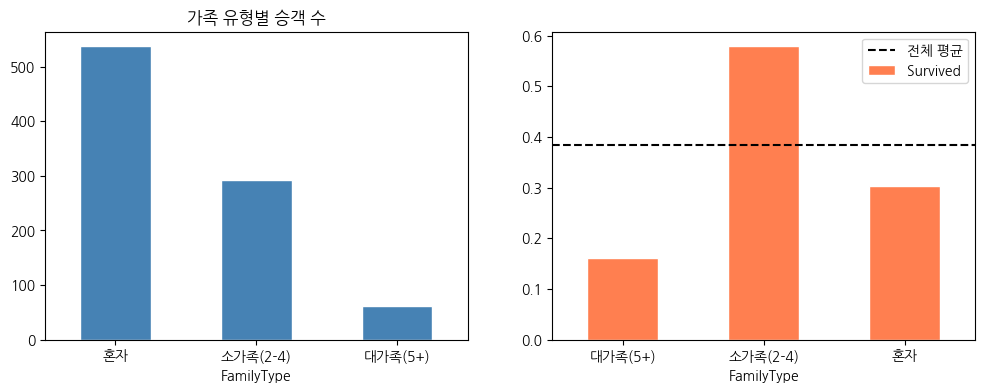

In [7]:
titanic_tf = titanic.copy()

# 가족 규모 파생 변수 생성
# sibsp: 형제/배우자 수, parch: 부모/자녀 수, +: 본인 포함
titanic_tf['FamilySize'] = titanic_tf['SibSp'] + titanic_tf['Parch'] + 1

# 혼자 탑승 여부 파생 변수 (0: 가족과 함께, 1: 혼자)
titanic_tf['IsAlone'] = (titanic_tf['FamilySize'] == 1).astype(int) #True->1, False->0으로 변환

# 가족 유형 범주화
def family_type(size):
  if size == 1:
    return '혼자'
  elif size <= 4:
    return '소가족(2-4)'
  else:
    return '대가족(5+)'
titanic_tf['FamilyType'] = titanic_tf['FamilySize'].apply(family_type) # apply()로 FamilySize 각 값에 family

# 결과 확인
print("가족 규모 분포:")
print(titanic_tf['FamilySize'].value_counts().sort_index())

print("\n 가족 유형별 생존율:")
print(titanic_tf.groupby('FamilyType')['Survived'].mean().round(3))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

titanic_tf['FamilyType'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('가족 유형별 승객 수')
axes[0].tick_params(axis='x', rotation=0)

titanic_tf.groupby('FamilyType')['Survived'].mean().plot(kind='bar', ax=axes[1],
                                                         color='coral', edgecolor='white')
axes[1].axhline(y=titanic_tf['Survived'].mean(), linestyle='--', color='black', label='전체 평균')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout
plt.show()

In [12]:
# 파생 변수 - 이름에서 호칭(Title) 추출

# Name 열 예시 확인: 형식 파악 후 정규표현식 설계에 활용
print(titanic_tf['Name'].head())

# 정규표현식으로 호칭(Title) 추출
titanic_tf['Title'] = titanic_tf['Name'].str.extract(r',\s*([^\.]+)\.')
# ,\s*([^\.]+)\. => 쉼표 뒤에 공백 0개 이상 마침표(.)가 아닌 문자 1개 이상 마침표로 끝나는 패턴
print("\n추출된 호칭 종류:")
print(titanic_tf['Title'].value_counts())

# 희귀 호칭율 'Other'로 통합
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
titanic_tf['Title_grouped'] = titanic_tf['Title'].apply(
    lambda x: x if x in common_titles else 'Other'
)
print("\n통합 후 호칭 분포:")
print(titanic_tf['Title_grouped'].value_counts())

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

추출된 호칭 종류:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

통합 후 호칭 분포:
Title_grouped
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64



호칭별 생존율:
Title_grouped
Mrs       0.792
Miss      0.698
Master    0.575
Other     0.444
Mr        0.157
Name: Survived, dtype: float64


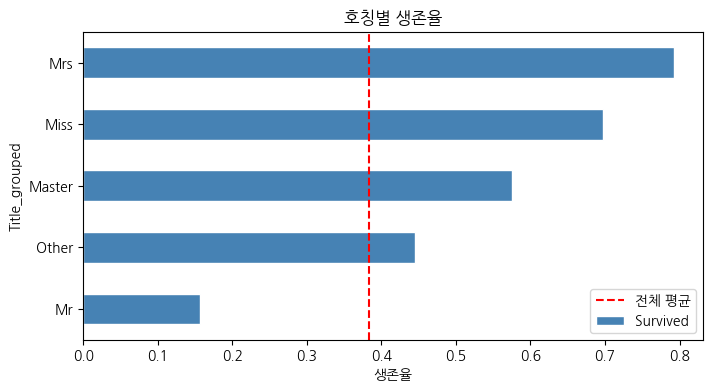

In [13]:
# 호칭별 생존율: 성별 사회적 지위가 생존에 미치는 영향 확인
survival_by_title = titanic_tf.groupby('Title_grouped')['Survived'].mean()
print("\n호칭별 생존율:")
print(survival_by_title.sort_values(ascending=False).round(3))

# 호칭별 생존율 시각화
survival_by_title.sort_values().plot(kind='barh', color='steelblue', figsize=(8, 4),
                                     edgecolor='white') #가로 막대 그래프
plt.axvline(x=titanic_tf['Survived'].mean(), color='red', linestyle='--', label='전체 평균')
plt.title('호칭별 생존율')
plt.xlabel('생존율')
plt.legend()

plt.tight_layout
plt.show()

### 구간화 (연속형 -> 범주형)

나이 구간 분포
AgeGroup
아동(0-12)       69
청소년(13-17)     44
성인(18-59)     575
노인(60+)        26
Name: count, dtype: int64

나이 구간별 생존율:
AgeGroup
아동(0-12)      0.580
청소년(13-17)    0.477
성인(18-59)     0.386
노인(60+)       0.269
Name: Survived, dtype: float64


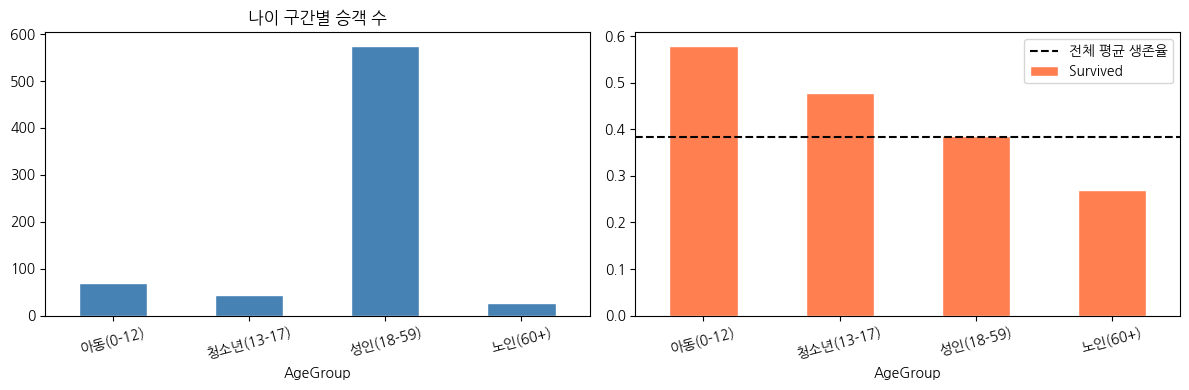

In [16]:
# pd.cut() - 나이 구간화 (도메인 기준), 지정한 경계값 기준으로 구간 분할, 각 구간의 데이터 계수가 달라도 됨
# 도메일 지식 기반 구간 정의
age_bins = [0, 12, 17, 59, 100]
age_labels = ['아동(0-12)', '청소년(13-17)', '성인(18-59)', '노인(60+)']

titanic_tf['AgeGroup'] = pd.cut(
    titanic_tf['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True # 오른쪽 경계값 포함 (0, 12)
)
print("나이 구간 분포")
print(titanic_tf['AgeGroup'].value_counts().sort_index())

# 구간별 생존율 : 나이 그룹이 생존에 영향을 미치는지 확인
survival_by_age = titanic_tf.groupby('AgeGroup', observed=True)['Survived'].mean()#observed=True: 데이터에 실제로 있는 카테고리만 표시
print("\n나이 구간별 생존율:")
print(survival_by_age.round(3))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

titanic_tf['AgeGroup'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
                                                        color='steelblue', edgecolor='white')
axes[0].set_title('나이 구간별 승객 수')
axes[0].tick_params(axis='x', rotation=15)

survival_by_age.plot(kind='bar', ax=axes[1],
                     color='coral', edgecolor='white')
axes[1].axhline(y=titanic_tf['Survived'].mean(), linestyle='--', color='black', label='전체 평균 생존율')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# pd.qcut() - 운임 구간화 (동일 비율)
# 4분위수로 균등 분할: 각 구간에 같은 개수의 데이터가 들어가도록 경계값 자동 설정
titanic_tf['FareQuartile'] = pd.qcut(
    titanic_tf['Fare'],
    q=4, # 4개 구간으로 분할
    labels=['저가(Q1)', '중저가(Q2)', '중고가(Q3)', '고가(Q4)']
)

print("\n[qcut] 각 구간의 개수 (균등):")
print(titanic_tf['FareQuartile'].value_counts().sort_index())

print("\n[qcut] 각 구간의 실제 경계값:")
print(pd.qcut(titanic_tf['Fare'], q=4).value_counts().sort_index())

# 운임 구간별 생존율: 비싼 티켓일수록 생존율이 높은지 확인
survival_by_fare = titanic_tf.groupby('FareQuartile', observed=True)['Survived'].mean()
print("\n운임 구간별 생존율:")
print(survival_by_fare.round(3))


[qcut] 각 구간의 개수 (균등):
FareQuartile
저가(Q1)     223
중저가(Q2)    224
중고가(Q3)    222
고가(Q4)     222
Name: count, dtype: int64

[qcut] 각 구간의 실제 경계값:
Fare
(-0.001, 7.91]     223
(7.91, 14.454]     224
(14.454, 31.0]     222
(31.0, 512.329]    222
Name: count, dtype: int64

운임 구간별 생존율:
FareQuartile
저가(Q1)     0.197
중저가(Q2)    0.304
중고가(Q3)    0.455
고가(Q4)     0.581
Name: Survived, dtype: float64


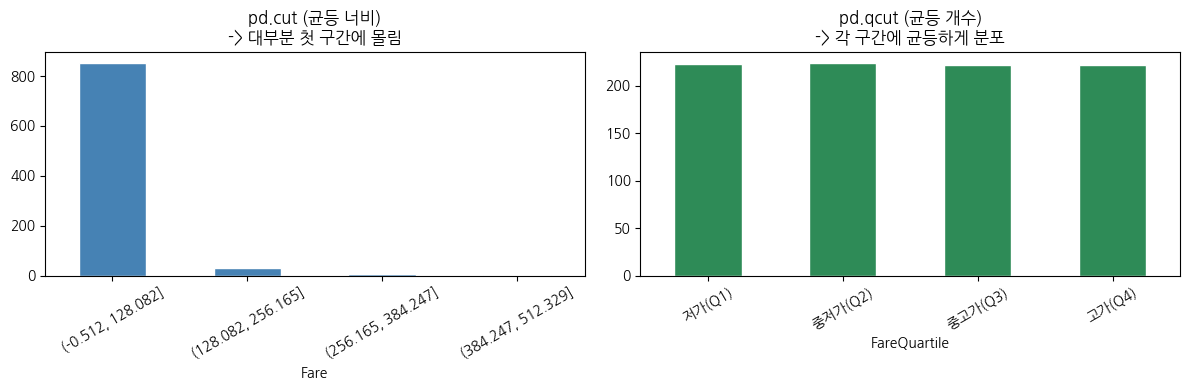

In [20]:
# cut vs qcut 구간 경계 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# cut: 균등 너비 분할
pd.cut(titanic_tf['Fare'], bins=4).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('pd.cut (균등 너비)\n-> 대부분 첫 구간에 몰림')
axes[0].tick_params(axis='x', rotation=30)

# qcut: 균등 개수 분할
titanic_tf['FareQuartile'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('pd.qcut (균등 개수)\n-> 각 구간에 균등하게 분포')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Box-Cox 변환 (자동 최적 변환)

최적 lambda 값:-0.0978


/tmp/ipykernel_1314/1931959989.py:20: UserWarning: Glyph 955 (\N{GREEK SMALL LETTER LAMDA}) missing from font(s) NanumGothic.
  plt.tight_layout()


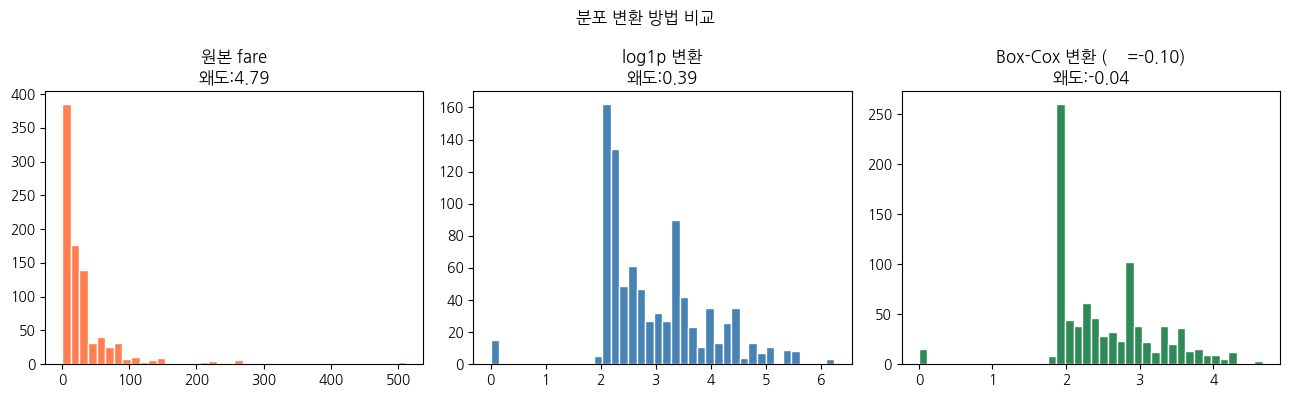

In [27]:
# Box-Cox 변환: 데이터에 맞는 최적의 lambda 값을 자동으로 찾아 정규분포에 가깝게 변환
# lambda 값: 데이터를 정규 분포(Normal Distribution)에 가장 가깝게 만들고, 등분산성(Homoscedasticity)을 확보

fare_positive = titanic['Fare'] + 1 # # Box-Cox는 x>0 조건 필요
fare_boxcox, lambda_val = stats.boxcox(fare_positive.dropna()) # 변환된 값 배열, 최적 lambda값
print(f"최적 lambda 값:{lambda_val:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(titanic['Fare'],bins=40, color='coral', edgecolor='white')
axes[0].set_title(f'원본 fare\n왜도:{titanic["Fare"].skew():.2f}')

axes[1].hist(np.log1p(titanic['Fare']),bins=40, color='steelblue', edgecolor='white')
axes[1].set_title(f'log1p 변환\n왜도:{np.log1p(titanic["Fare"]).skew():.2f}')

axes[2].hist(fare_boxcox, bins=40, color='seagreen', edgecolor='white')
axes[2].set_title(f'Box-Cox 변환 (λ ={lambda_val:.2f})\n왜도:{pd.Series(fare_boxcox).skew():.2f}')
#최적의 lambda 값이 0에 가까울수록 로그 변환, 1이면 변환 없음, 0.5면 제곱근 변환
plt.suptitle('분포 변환 방법 비교', fontsize=12)
plt.tight_layout()
plt.show()

### 날짜/시간 데이터 처리

In [30]:
# 타이타닉 침몰 날짜 기반
import random
random.seed(42)

# 탑승 날짜 시뮬레이션 예시 데이터 생성
titanic_tf['BoardingDate'] = pd.to_datetime( # 문자열을 datetime 타입으로 변환
    ['1912-04-12', '1912-04-13', '1912-04-14'] * (len(titanic_tf) // 3 + 1)
    )[:len(titanic_tf)]# 전체 행 수만큼 잘라서 사용
titanic_tf['BoardingDate'].tail()

,BoardingDate
886,1912-04-13
887,1912-04-14
888,1912-04-12
889,1912-04-13
890,1912-04-14


In [31]:
# datetime 구성 요소 추출: .dt 접근자로
titanic_tf['BoardMonth'] = titanic_tf['BoardingDate'].dt.month
titanic_tf['BoardDay'] = titanic_tf['BoardingDate'].dt.day
titanic_tf['BoardWeekday'] = titanic_tf['BoardingDate'].dt.day_name()

titanic_tf['is_weekend'] = (titanic_tf['BoardWeekday'].isin(['Saturday', 'Sunday'])).astype(int)
titanic_tf['is_holiday_season'] = titanic_tf['BoardMonth'].isin([4, 5, 6]).astype(int) #1(성수기)

# 결과 확인

print("추출된 날짜 열:")
print(titanic_tf[['BoardingDate', 'BoardMonth', 'BoardDay', 'BoardWeekday', 'is_weekend', 'is_holiday_season']].head())

추출된 날짜 열:
  BoardingDate  BoardMonth  BoardDay BoardWeekday  is_weekend  \
0   1912-04-12           4        12       Friday           0   
1   1912-04-13           4        13     Saturday           1   
2   1912-04-14           4        14       Sunday           1   
3   1912-04-12           4        12       Friday           0   
4   1912-04-13           4        13     Saturday           1   

   is_holiday_season  
0                  1  
1                  1  
2                  1  
3                  1  
4                  1  


### 타이타닉 전처리

In [ ]:
titanic_final = titanic.copy()
# 1: 결측치 처리
titanic_final['Age'] =
titanic_final['Embarked'] =
## Cabin 열 삭제

# 2: 이상치 처리
titanic_final['Fare']

# 3: 분포 변환
## np.log1p

# 4: 구간화
## pd.cut
## pd.qcut

# 5: 파생 변수

# 결과 확인
# titanic_final.shape